In [178]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

In [179]:
data = pd.read_csv("novagen_dataset.csv")

In [180]:
data.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [181]:
cat_classes = ["Diet_Type__Vegan","Diet_Type__Vegetarian","Blood_Group_AB","Blood_Group_B","Blood_Group_O"]

In [182]:
from sklearn.preprocessing import LabelEncoder

In [183]:
le = LabelEncoder()
for col in cat_classes:
    data[col] = le.fit_transform(data[col]) 

In [184]:
X = data.drop(["Target","Diet","Diet_Type__Vegan","Diet_Type__Vegetarian","Blood_Group_AB","Blood_Group_B","Blood_Group_O"], axis=1)
y = data["Target"]

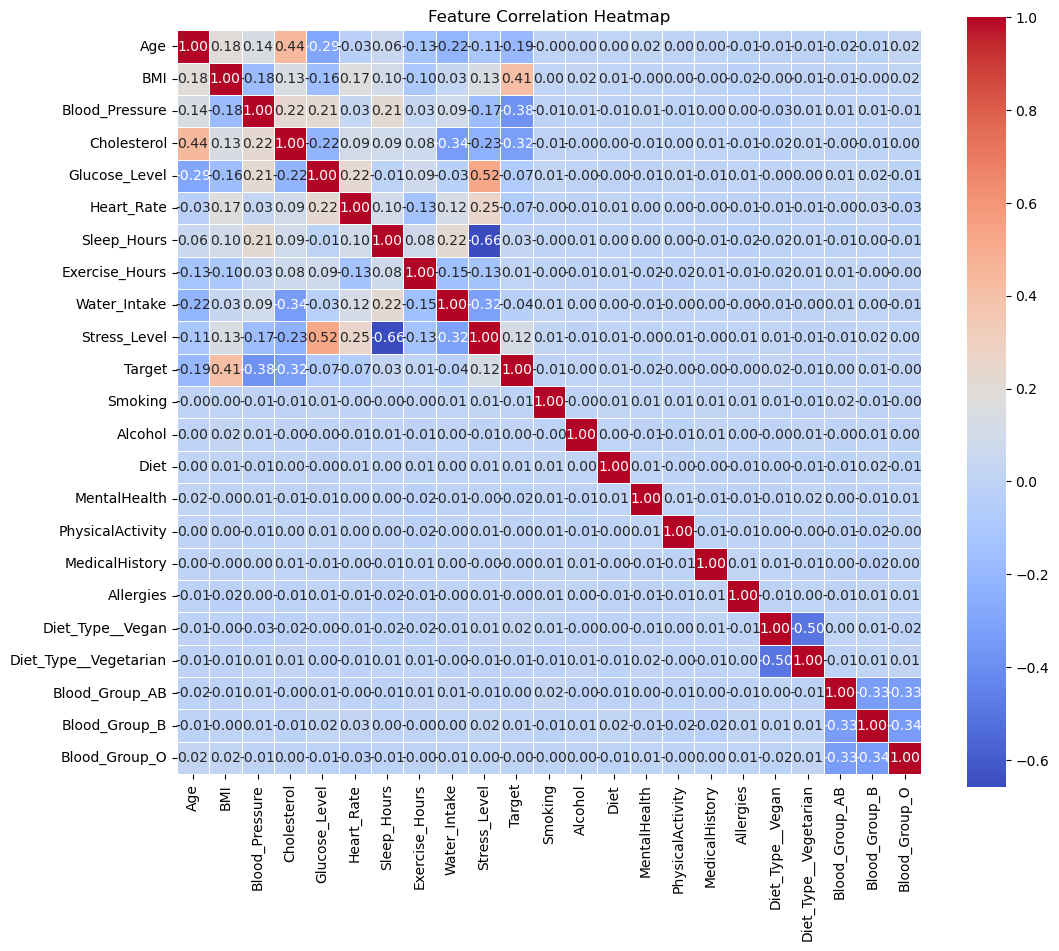

In [185]:
corr_matrix = data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.show()

In [186]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42,stratify=y)

# Logistic Regression

In [187]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

In [188]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2,interaction_only=True)),
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(
        max_iter=5000,
        solver='saga', 
        C=0.5
    ))
])

poly_model.fit(X_train, y_train)
y_pred = poly_model.predict(X_test)

print(f"Test Accuracy: {poly_model.score(X_test, y_test)*100:.2f}")
print("cr:\n", classification_report(y_test, y_pred))

Test Accuracy: 87.28
cr:
               precision    recall  f1-score   support

           0       0.87      0.86      0.87      1508
           1       0.87      0.89      0.88      1644

    accuracy                           0.87      3152
   macro avg       0.87      0.87      0.87      3152
weighted avg       0.87      0.87      0.87      3152



In [189]:
scores_lr = cross_val_score(
    poly_model, 
    X, 
    y, 
    cv=5, 
    scoring='recall'
)

print("Logistic CV Recall:", scores_lr)
print("Mean Recall:", scores_lr.mean())

Logistic CV Recall: [0.87851406 0.89457831 0.88052209 0.88554217 0.90753769]
Mean Recall: 0.889338862989647


# Naive Bayes

In [190]:
from sklearn.naive_bayes import GaussianNB

In [191]:
nb = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])


nb.fit(X_train,y_train)
y_pred = nb.predict(X_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

Naive Bayes Accuracy: 80.93
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.83      0.81      1508
           1       0.83      0.79      0.81      1644

    accuracy                           0.81      3152
   macro avg       0.81      0.81      0.81      3152
weighted avg       0.81      0.81      0.81      3152



In [192]:
scores_nb = cross_val_score(
    nb, 
    X, 
    y, 
    cv=5, 
    scoring='recall'
)

print("Naive Bayes CV Recall:", scores_nb)
print("Mean Recall:", scores_nb.mean())

Naive Bayes CV Recall: [0.81626506 0.81024096 0.80421687 0.79718876 0.80603015]
Mean Recall: 0.8067883594680229


# Random Forest

In [193]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [194]:
rf = RandomForestClassifier(
    n_estimators=300, 
    max_depth=10, 
    min_samples_leaf=2, 
    min_samples_split=5, 
    max_features='sqrt', 
    class_weight='balanced', 
    random_state=42
)


param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Pass param_grid as the second argument
grid = GridSearchCV(
    rf, 
    param_grid,
    cv=5, 
    scoring='recall', 
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

In [195]:
y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}")


from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_rf, X, y, cv=5, scoring='recall')

print("Cross-validation Recall Scores:", scores)
print("Mean Recall:", scores.mean())

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1508
           1       0.94      0.97      0.95      1644

    accuracy                           0.95      3152
   macro avg       0.95      0.95      0.95      3152
weighted avg       0.95      0.95      0.95      3152

Random Forest Accuracy: 94.89
Cross-validation Recall Scores: [0.95783133 0.95381526 0.9497992  0.95381526 0.95778894]
Mean Recall: 0.954609997780065


# Voting

In [196]:
from sklearn.ensemble import VotingClassifier

In [197]:
voting = VotingClassifier(
    estimators=[
        ('lr', poly_model),
        ('rf', best_rf),
        ('nb', nb)
    ],            
    weights=[2, 4, 1]
)

In [198]:
voting.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[2, 4, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",True
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


In [199]:
y_pred = voting.predict(X_test)

print("Voting Classifier Results:\n")
print(classification_report(y_test, y_pred))
print(f"Voting Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}")

Voting Classifier Results:

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1508
           1       0.94      0.97      0.95      1644

    accuracy                           0.95      3152
   macro avg       0.95      0.95      0.95      3152
weighted avg       0.95      0.95      0.95      3152

Voting Accuracy: 94.89


In [200]:
scores_voting = cross_val_score(
    voting, 
    X, 
    y, 
    cv=5, 
    scoring='recall'
)

print("Voting CV Recall:", scores_voting)
print("Mean Recall:", scores_voting.mean())

Voting CV Recall: [0.95783133 0.95381526 0.9497992  0.95381526 0.95778894]
Mean Recall: 0.954609997780065


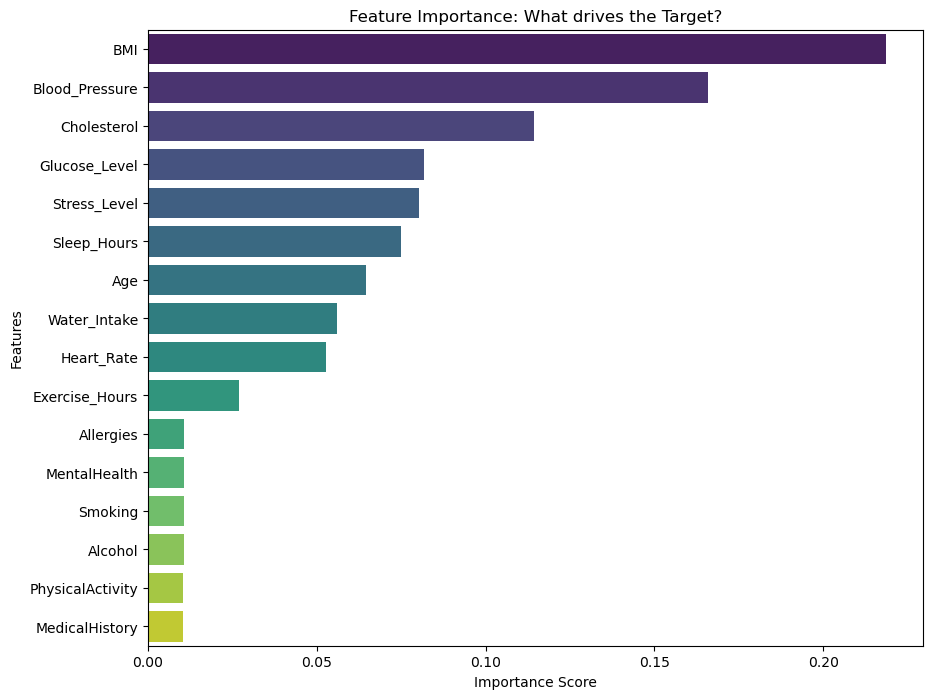

In [201]:
importances = best_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df, 
    hue='Feature', 
    palette='viridis', 
    legend=False 
)
plt.title('Feature Importance: What drives the Target?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

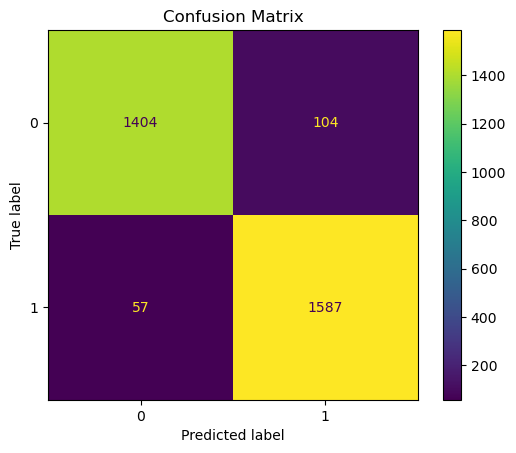

In [202]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()